# Linear Attention & GLA：把 O(S²) 变成 O(S) 的线性递归

> 标准 attention 是 `softmax(QKᵀ)V`，O(S²)。**linear attention** 去掉 softmax、换成 feature map φ，
> 靠**结合律** `φ(Q)(φ(K)ᵀV)` 变成 O(S)：先把 `Σφ(k)vᵀ` 累成一个状态矩阵，再让每个 query 去乘。
> **GLA** 再给状态加一个 data-dependent 的衰减门控，补回"选择性遗忘"。

本章两版本：`linear.py`（自写三形式 + GLA ground truth）+ 深度优化版（**解耦自 fla** 的 GLA
chunk-parallel triton kernel，已脱离 fla 包独立运行）。

In [1]:
import sys, math
from pathlib import Path

import torch
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

ROOT = Path.cwd()
while not (ROOT / "common").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT)); sys.path.insert(0, str(ROOT / "10-linear-attention"))

from common import bench_ms
from linear import (linear_attn_parallel, linear_attn_recurrent, linear_attn_chunked, gla_recurrent)

torch.manual_seed(0)
print("跑在", torch.cuda.get_device_name(0))

# 中文正常显示 + 暗色代码高亮（适配深色编辑器），见 common/nbtools.py
from common.nbtools import setup_cjk, show_code
setup_cjk()


跑在 NVIDIA GeForce RTX 4090


'Noto Sans SC'

## 1. 从 softmax 到 linear：一个结合律的事

`exp(qᵢ·kⱼ)` 换成 `φ(qᵢ)·φ(kⱼ)` 后，分子 `Σⱼ (φqᵢ·φkⱼ) vⱼ = φqᵢ · (Σⱼ φkⱼ vⱼᵀ)`。括号里那项
**与 query 无关**，是个 D×D 的"状态矩阵"。先累状态、再乘 query → **O(S·D²)，序列长度上线性**。

下面验证：同一 causal linear attention 的三种形式（parallel / recurrent / chunked）数值一致。

In [2]:
q, k, v = (torch.randn(2, 4, 512, 64, device="cuda") for _ in range(3))
par = linear_attn_parallel(q, k, v, causal=True)
rec = linear_attn_recurrent(q, k, v)
chk = linear_attn_chunked(q, k, v, chunk_size=64)
print("parallel vs recurrent  max diff:", (par - rec).abs().max().item())
print("chunked  vs recurrent  max diff:", (chk - rec).abs().max().item())
print("→ 三种形式等价：parallel 看得清、recurrent 是 O(1)/步的推理形式、chunked 是训练高效形式。")

parallel vs recurrent  max diff: 0.00634765625
chunked  vs recurrent  max diff: 0.001953125
→ 三种形式等价：parallel 看得清、recurrent 是 O(1)/步的推理形式、chunked 是训练高效形式。


## 2. 复杂度：O(S) vs O(S²)

linear/GLA 的卖点是**长序列**。下面对比 full attention（SDPA / FlashAttention 后端，O(S²)）与 GLA
chunk kernel（O(S)）的延迟随序列长度的变化 —— 序列越长，线性的优势越大。

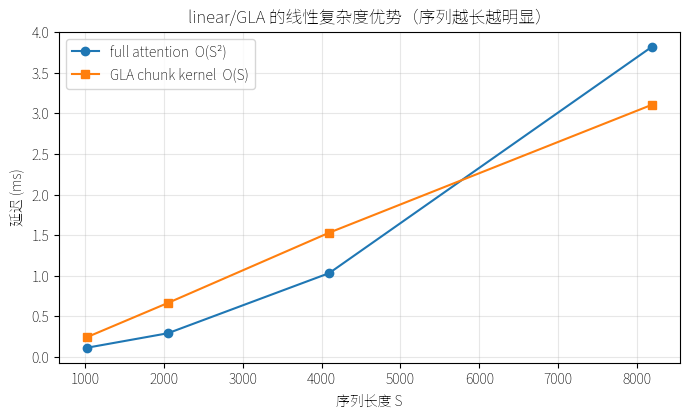

S= 1024: full  0.116ms | GLA  0.247ms | 加速 0.47×
S= 2048: full  0.293ms | GLA  0.666ms | 加速 0.44×
S= 4096: full  1.033ms | GLA  1.531ms | 加速 0.68×
S= 8192: full  3.818ms | GLA  3.105ms | 加速 1.23×


In [3]:
from gla_triton import gla_chunk

Ss = [1024, 2048, 4096, 8192]
t_full, t_gla = [], []
for S in Ss:
    qf = torch.randn(4, 8, S, 128, device="cuda", dtype=torch.float16)
    kf = torch.randn(4, 8, S, 128, device="cuda", dtype=torch.float16)
    vf = torch.randn(4, 8, S, 128, device="cuda", dtype=torch.float16)
    qb, kb, vb = (x.to(torch.bfloat16) for x in (qf, kf, vf))
    g = F.logsigmoid(torch.randn(4, 8, S, 128, device="cuda", dtype=torch.float32))
    t_full.append(bench_ms(lambda: F.scaled_dot_product_attention(qf, kf, vf, is_causal=True)))
    t_gla.append(bench_ms(lambda: gla_chunk(qb, kb, vb, g)))

plt.figure(figsize=(7, 4.3))
plt.plot(Ss, t_full, "o-", label="full attention  O(S²)")
plt.plot(Ss, t_gla, "s-", label="GLA chunk kernel  O(S)")
plt.xlabel("序列长度 S"); plt.ylabel("延迟 (ms)"); plt.legend()
plt.title("linear/GLA 的线性复杂度优势（序列越长越明显）")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
for S, a, b in zip(Ss, t_full, t_gla):
    print(f"S={S:>5}: full {a:6.3f}ms | GLA {b:6.3f}ms | 加速 {a/b:.2f}×")

## 3. GLA：给状态加"选择性遗忘"

linear attention 的状态只加不减（远古信息永不衰减）。**GLA** 加一个 data-dependent 的衰减 αₜ=exp(gₜ)：

$$S_t = \operatorname{diag}(\alpha_t) S_{t-1} + k_t v_t^\top$$

效果上，query 对 t 步前的 key 的**有效权重**会乘上累积衰减 `∏α ≈ exp(g·t)`。门控 g 越负，遗忘越快。

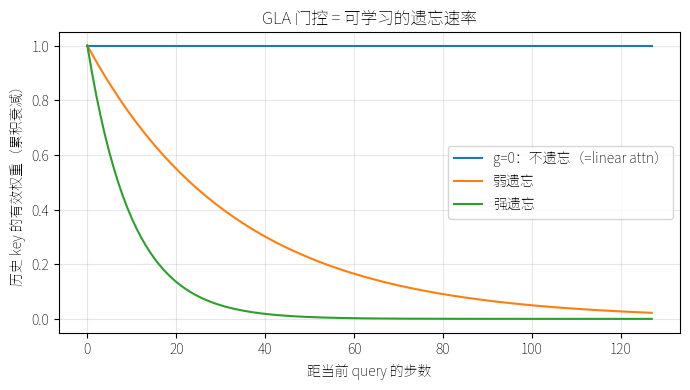

GLA(g=0) vs linear attention  max diff: 0.0


In [4]:
S = 128
plt.figure(figsize=(7, 4))
for g_val, name in [(0.0, "g=0：不遗忘（=linear attn）"), (-0.03, "弱遗忘"), (-0.1, "强遗忘")]:
    plt.plot(np.exp(g_val * np.arange(S)), label=name)
plt.xlabel("距当前 query 的步数"); plt.ylabel("历史 key 的有效权重（累积衰减）")
plt.legend(); plt.title("GLA 门控 = 可学习的遗忘速率"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

q, k, v = (torch.randn(2, 4, 128, 64, device="cuda") for _ in range(3))
gla0 = gla_recurrent(q, k, v, torch.zeros_like(q))
lin = linear_attn_recurrent(q * (64 ** -0.5), k, v, phi=lambda x: x)
print("GLA(g=0) vs linear attention  max diff:", (gla0 - lin).abs().max().item())

## 4. 深度优化版：真正的 GLA chunk-parallel triton kernel

上面的 `linear.py` 是教学 reference（recurrent 串行、chunked 用 PyTorch GEMM）。**真正高效的训练**靠
手写 triton kernel。本仓库把 fla 的 GLA chunk-parallel kernel **解耦到本地三件套**（计算逻辑一字未改，
仅改 import 脱离 fla，见 `SOURCES.md`）：

| 文件 | 职责 |
|---|---|
| `_fla_gla_chunk.py` | **主 kernel**：块内并行 attention + 块间状态合并 + 门控（下面完整展示）|
| `_fla_chunk_h.py` | 块间递归状态 H 的前向/反向 `chunk_fwd_h`/`chunk_bwd_dh`（带门控衰减）|
| `_fla_cumsum.py` | 门控的块内累积 `chunk_local_cumsum`（log decay 的 prefix-sum）|

下面**完整展示主 kernel 源码**（这才是深度优化版的核心；后面逐段拆解）：

In [5]:
from IPython.display import Code
show_code(str(ROOT / "10-linear-attention" / "_fla_gla_chunk.py"))

### 逐段读懂 chunk-parallel forward（`chunk_gla` / `chunk_gla_fwd`）

GLA 的 chunk-parallel = 把序列切成 chunk，**块内并行、块间递归**，并把门控织进去：

**① 门控先做块内累积**
```python
g = chunk_local_cumsum(g, chunk_size, ...)   # 每个 chunk 内对 log-decay 做 prefix-sum，得 bᵢ
```
`bᵢ = Σ_{j≤i within chunk} gⱼ`。块内 query i 对 key j 的权重要乘 `exp(bᵢ - bⱼ)`（相对衰减），块间要乘
整段衰减 —— 这就是 GLA 的门控落点（`_fla_cumsum.py`）。

**② 块间递归状态 H（跨 chunk 的"记忆"）**
```python
h, ... = chunk_fwd_h(k, v, g, ...)   # 沿 chunk 维递推：Hₜ = decay·Hₜ₋₁ + Σ_chunk (k⊙衰减)vᵀ
```
`chunk_fwd_h`（`_fla_chunk_h.py`）算每个 chunk 起点的状态矩阵 H —— 它携带了**前面所有 chunk** 的信息，
带门控衰减。这是 O(块数) 的递归部分。

**③ 块内 attention + 块间贡献，合并**
```python
# o = 块内(下三角 q·kᵀ·衰减)·v  +  块间(q·衰减·H)
```
块内用矩阵乘并行算（GEMM，GPU 友好），块间用 ② 的 H 一次乘出。两者相加 = 完整 GLA 输出。**既有并行度
（块内 GEMM）又是线性复杂度（块间递归）**，这正是 chunk-parallel 训练高效的原因。

**④ 变长 cu_seqlens（sequence packing）**
```python
if cu_seqlens is not None:
    chunk_indices = prepare_chunk_indices(cu_seqlens, BT)   # 每个 chunk 属于哪条序列、序列内第几块
```
多条变长序列拼成一个 batch 时（`[seqA|seqB|seqC]`），`cu_seqlens` 标记边界，`prepare_chunk_indices`
（本仓库从 fla 拷的纯 torch 索引，见 `_fla_compat.py`）让 kernel **按序列分块、不跨序列 attend**。
这是 LLM 训练/推理里把不等长样本打包进同一 batch 的标准做法。

### backward 与"怎么脱离 fla"

- **backward**：`chunk_bwd_dh`（`_fla_chunk_h.py`）沿 chunk 维**反向**递推状态梯度 dH，再配合块内反向算
  dq/dk/dv/dg。结构与 forward 对称（块内并行 + 块间递归）。
- **脱离 fla**：上面 kernel 对 fla 框架的依赖全是"工具/适配"符号 —— `exp2`、autotune 缓存、
  `check_shared_mem`（选 block 大小）、`input_guard`、变长索引。本仓库用一层薄适配 `_fla_compat.py`
  把它们复现（autotune 缓存→标准 `triton.autotune`；`check_shared_mem`→torch 查 GPU shared mem；
  变长索引→从 fla 拷的纯 torch 函数），**只改 import、计算逻辑零改动**。下面是这层适配的全部源码：

In [6]:
show_code(str(ROOT / "10-linear-attention" / "_fla_compat.py"))

### 验证：解耦没改任何计算

定长 + 变长（cu_seqlens）两种场景，本地解耦 kernel 都与 fla 原版近 bitwise 一致；并与简要版 recurrent
ground truth 对齐。

In [7]:
from _fla_gla_chunk import chunk_gla as local_chunk_gla
B, H, T, D = 2, 4, 512, 64
gg = torch.Generator("cuda").manual_seed(1)
q = torch.randn(B, T, H, D, device="cuda", dtype=torch.bfloat16, generator=gg)
k = torch.randn(B, T, H, D, device="cuda", dtype=torch.bfloat16, generator=gg)
v = torch.randn(B, T, H, D, device="cuda", dtype=torch.bfloat16, generator=gg)
g = F.logsigmoid(torch.randn(B, T, H, D, device="cuda", dtype=torch.float32, generator=gg))

o_local, _ = local_chunk_gla(q, k, v, g)
try:
    from fla.ops.gla import chunk_gla as fla_chunk_gla
    o_fla, _ = fla_chunk_gla(q, k, v, g)
    print("① 定长：本地解耦 vs fla 原版   max diff:", (o_local.float() - o_fla.float()).abs().max().item())
    # 变长 / sequence packing
    cu = torch.tensor([0, 128, 328, 512], device="cuda", dtype=torch.int32)  # 3 条序列拼成一个 batch
    qp, kp, vp = (x.reshape(1, B * T, H, D) for x in (q, k, v))
    gp = g.reshape(1, B * T, H, D)
    cu2 = torch.tensor([0, 200, 512, 800, 1024], device="cuda", dtype=torch.int32)
    o_l2, _ = local_chunk_gla(qp, kp, vp, gp, cu_seqlens=cu2)
    o_f2, _ = fla_chunk_gla(qp, kp, vp, gp, cu_seqlens=cu2)
    print("② 变长(cu_seqlens)：本地 vs fla    max diff:", (o_l2.float() - o_f2.float()).abs().max().item())
except ImportError:
    print("（未装 fla，跳过原版对照）")

o_rec = gla_recurrent(*(x.transpose(1, 2) for x in (q, k, v, g))).transpose(1, 2)
print("③ 本地 chunk vs 简要版 recurrent   max diff:", (o_local.float() - o_rec.float()).abs().max().item())
print("→ 解耦（含变长索引）没改任何计算，与 fla 原版 bitwise 一致、与 recurrent ground truth 对齐。")

① 定长：本地解耦 vs fla 原版   max diff: 0.0


② 变长(cu_seqlens)：本地 vs fla    max diff: 0.0
③ 本地 chunk vs 简要版 recurrent   max diff: 0.0625
→ 解耦（含变长索引）没改任何计算，与 fla 原版 bitwise 一致、与 recurrent ground truth 对齐。


## 5. 收尾

- **simple**（`linear.py`）：linear attention 三形式 + GLA recurrent，讲清"结合律省算 O(S)"与门控机制。
- **deep**（解耦的 fla GLA kernel）：真正的 chunk-parallel triton 实现 —— 块内并行 + 块间递归 + 门控
  累积 + 变长 packing；用一层薄适配脱离 fla，计算逻辑一字未改、与原版 bitwise 一致。

> 下一站 → 11-deltanet：DeltaNet 用 **delta rule** 让状态做"增量更新"（写入前先擦掉旧的相关记忆），
> 比 GLA 的逐维衰减更接近"在线学习"。同样来自 fla，可复用本章的解耦套路。